In [1]:
import numpy as np
import xroms
from glob import glob
import matplotlib.pyplot as plt
import xarray as xr
import warnings
import sys
import xrft
sys.path.append("/homes/metogra/iufarias/FeedbackSubmeso/useful/")
import romspickle
import matplotlib.colors as colors
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import datetime
import cmocean as cm
from matplotlib.gridspec import GridSpec
import matplotlib.patheffects as PathEffects

warnings.filterwarnings("ignore")

import seawater as sw
import matplotlib.gridspec as gridspec

In [2]:
!rm /homes/metogra/iufarias/.cache/matplotlib/fontlist*

plt.rcParams.update({'font.size': 14})
# plt.rcParams.update({'font.weight': 'bold'})
# plt.rc('font',**{'family':'serif','serif':['Helvetica']})

plt.rcParams['font.family'] = 'sans-serif'
# plt.rcParams['font.sans-serif'] = ['Lucida Grande']
plt.rcParams['font.sans-serif'] = ['Helvetica']
plt.rcParams['axes.linewidth'] = 1.1

plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['mathtext.rm'] = 'Times New Roman'
plt.rcParams['text.usetex'] = True

props = dict(boxstyle='round', facecolor='wheat', alpha=1)


In [3]:
def ogive(deltaf,G):
    '''
    ogive(deltaf,G): use very simple integration to calculate the ogive 
    from a spectrum G with data sampled at frequency deltaf.
    2017-01-10T09:40:31 going back to a single frequency for Os and Gs
    '''
    M1 = len(G)
    Og = np.zeros(M1,float)
    Og[0:M1] = np.cumsum(np.flipud(G[0:M1]))
    Og *= deltaf
    Og = np.flipud(Og)
    return Og



## Reading WRF(3D)

In [4]:
# chunks={'time_counter':1}

# varfw=xr.open_mfdataset('/data/pacific/lrenault/SASI/FULL/WRF/wrf_3D_Y2012M*DAY.nc',data_vars='minimal')
# vartw=xr.open_mfdataset('/data/pacific/lrenault/SASI/SMTH/WRF/wrf_3D_Y2012M*DAY.nc',data_vars='minimal')

varfw=xr.open_mfdataset('/data/pacific/lrenault/SASI/FULL/WRF/wrfout_Y2012M*.nc',data_vars='minimal')
vartw=xr.open_mfdataset('/data/pacific/lrenault/SASI/SMTH/WRF/wrfout_Y2012M*.nc',data_vars='minimal')


## Analysis

In [6]:
xcoast=215

In [7]:
w_full=varfw.W.compute().isel(x_grid_M=slice(0,xcoast))
# sst_full=varfw.SST.compute().isel(x_grid_M=slice(0,xcoast))-273.15
pbl_full=varfw.PBLH.compute().isel(x_grid_M=slice(0,xcoast))

In [8]:
w_smth=vartw.W.compute().isel(x_grid_M=slice(0,xcoast))
# sst_smth=vartw.SST.compute().isel(x_grid_M=slice(0,xcoast))-273.15
pbl_smth=vartw.PBLH.compute().isel(x_grid_M=slice(0,xcoast))

In [9]:
u_full_g=varfw.U.compute()
v_full_g=varfw.V.compute()

u_full=((u_full_g[:,:,:,1:] + u_full_g[:,:,:,:-1])/2).isel(x_grid_U=slice(0,xcoast))
v_full=((v_full_g[:,:,1:,:] + v_full_g[:,:,:-1,:])/2).isel(x_grid_V=slice(0,xcoast))

# div_full=u_full.differentiate('x_grid_U')/2e3 + v_full.differentiate('y_grid_V').values/2e3

u_smth_g=vartw.U.compute()
v_smth_g=vartw.V.compute()

u_smth=((u_smth_g[:,:,:,1:] + u_smth_g[:,:,:,:-1])/2).isel(x_grid_U=slice(0,xcoast))
v_smth=((v_smth_g[:,:,1:,:] + v_smth_g[:,:,:-1,:])/2).isel(x_grid_V=slice(0,xcoast))

# div_smth=u_smth.differentiate('x_grid_U')/2e3 + v_smth.differentiate('y_grid_V').values/2e3


In [10]:
lat_rho=w_full['nav_lat_grid_M']
lon_rho=w_full['nav_lon_grid_M']

In [11]:
Z=((varfw['PH'] + varfw['PHB'])/9.8).isel(x_grid_M=slice(0,xcoast)).compute()
Z_m=Z[:,1:,:,:].data/2 + Z[:,:-1,:,:]/2


# Spectral Analysis

In [12]:
nf=4
dxx=2000
sclstr='density'
wdws='hann' #'flattop','hann'
wdw_cor=True
phase_bol=True
truncate_bol=True

color2='red'
color1='cornflowerblue'

## KE

In [13]:
%%time
levm=0
u_full_spec=xrft.isotropic_power_spectrum(u_full.isel(lev_M=levm),
                                          dim=['y_grid_U','x_grid_U'],scaling=sclstr,true_phase = phase_bol,
                                          truncate=truncate_bol, window=wdws,window_correction=wdw_cor)
v_full_spec=xrft.isotropic_power_spectrum(v_full.isel(lev_M=levm),
                                          dim=['y_grid_V','x_grid_V'],scaling=sclstr,true_phase = phase_bol,
                                          truncate=truncate_bol, window=wdws,window_correction=wdw_cor)


u_smth_spec=xrft.isotropic_power_spectrum(u_smth.isel(lev_M=levm),
                                          dim=['y_grid_U','x_grid_U'],scaling=sclstr,true_phase = phase_bol,
                                          truncate=truncate_bol, window=wdws,window_correction=wdw_cor)
v_smth_spec=xrft.isotropic_power_spectrum(v_smth.isel(lev_M=levm),
                                          dim=['y_grid_V','x_grid_V'],scaling=sclstr,true_phase = phase_bol,
                                          truncate=truncate_bol, window=wdws,window_correction=wdw_cor)


eke_full_spec=0.5*(u_full_spec+v_full_spec)
eke_smth_spec=0.5*(u_smth_spec+v_smth_spec)

CPU times: user 3.88 s, sys: 727 ms, total: 4.6 s
Wall time: 4.65 s


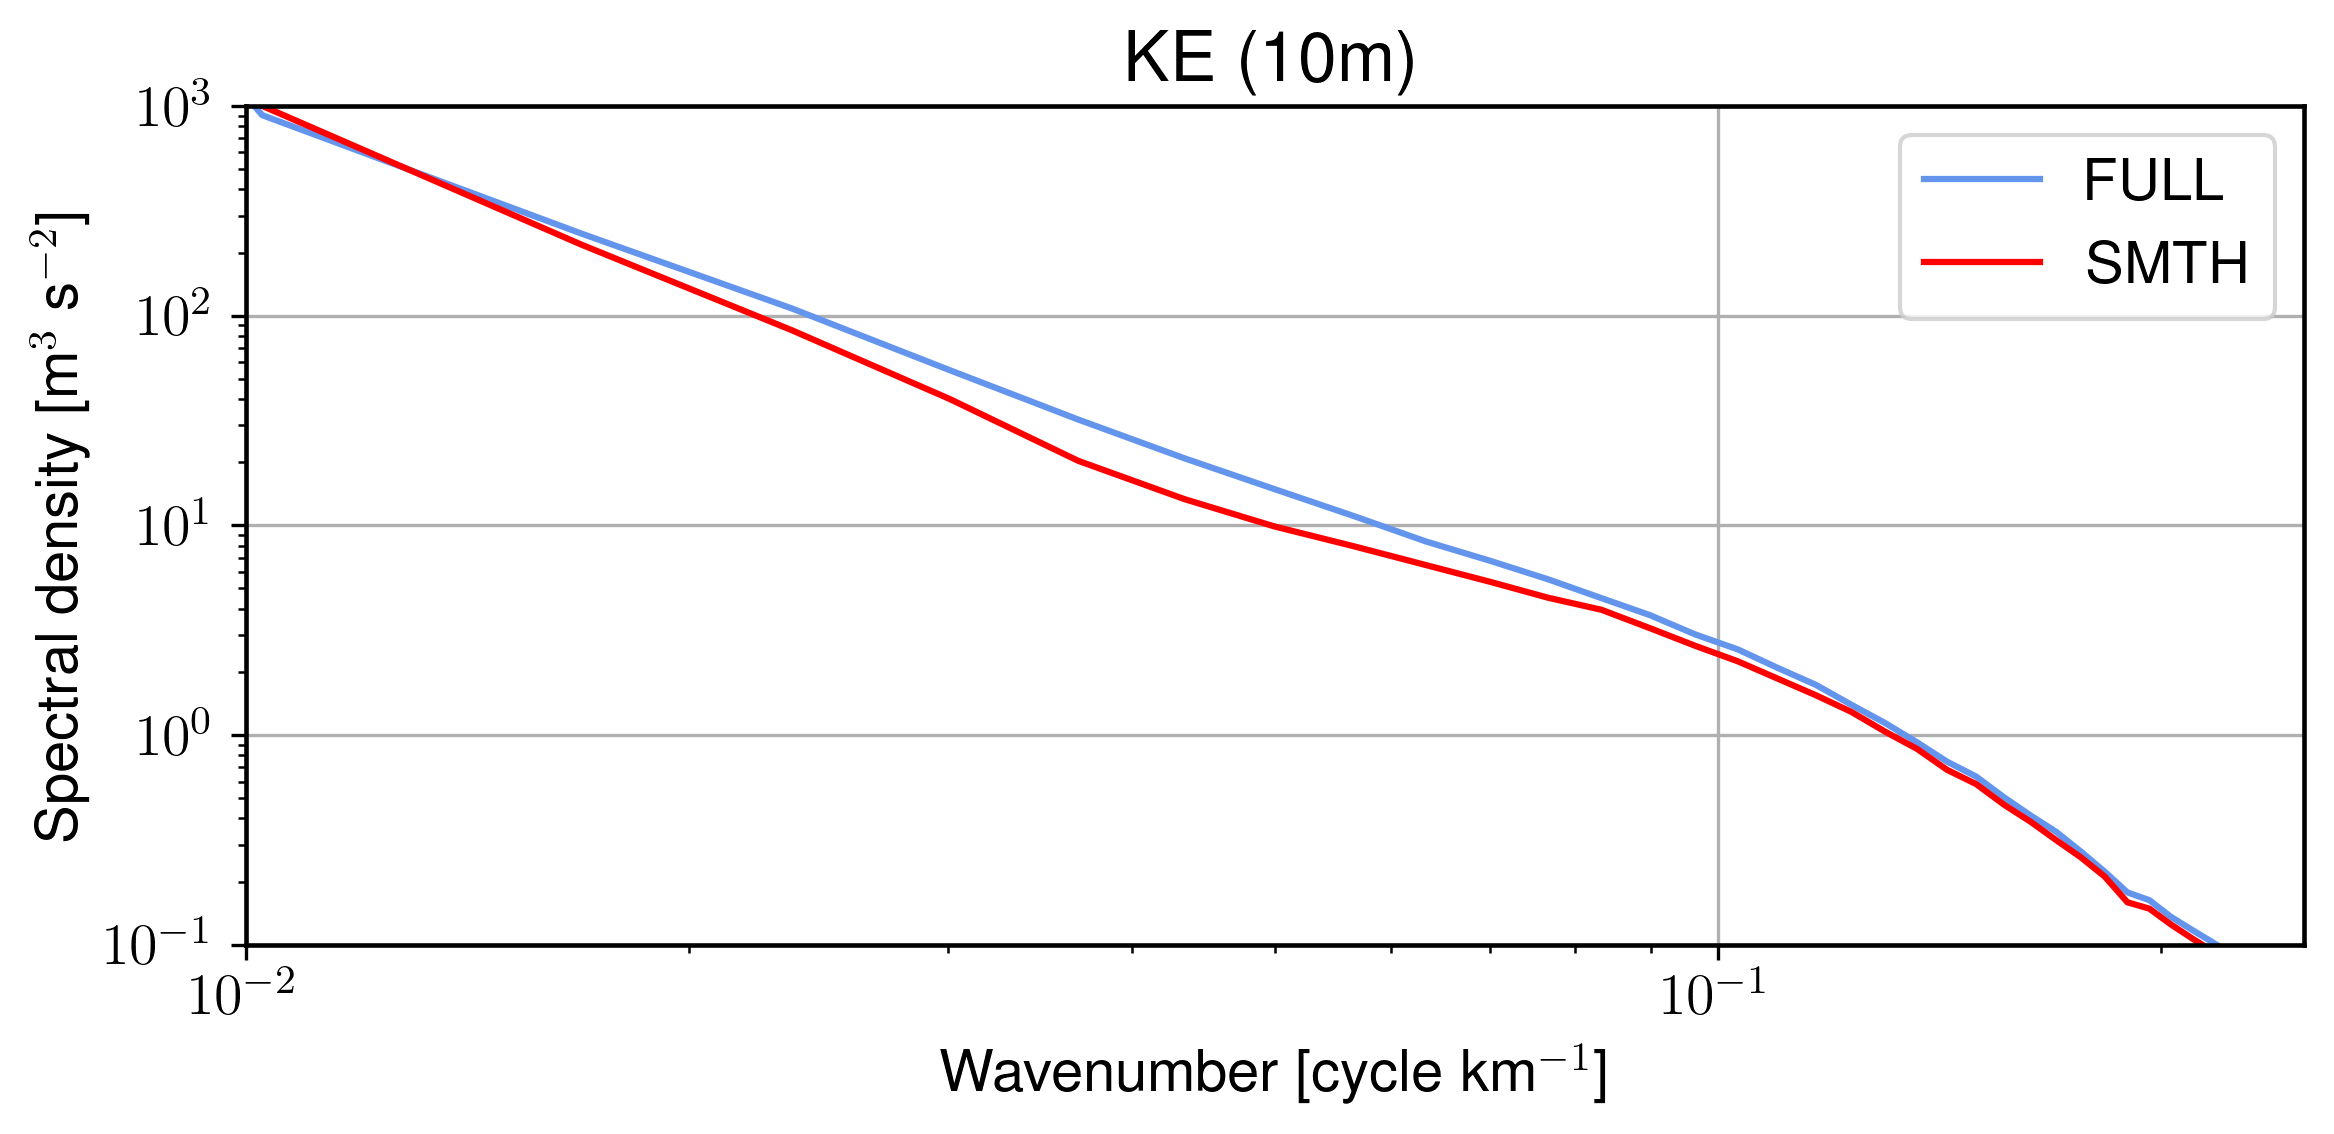

In [14]:
plt.figure(figsize=(8,4),dpi=300)

plt.plot(eke_full_spec['freq_r']/dxx*1e3,eke_full_spec.mean('time_counter')*dxx,label='FULL',color=color1)
plt.plot(eke_smth_spec['freq_r']/dxx*1e3,eke_smth_spec.mean('time_counter')*dxx,label='SMTH',color=color2)


plt.yscale('log')
plt.xscale('log')
plt.legend()
plt.grid()
plt.xlabel(r'Wavenumber [cycle km$^{-1}$]')
plt.ylabel(r'Spectral density [m$^3$ s$^{-2}$]')
plt.title('KE ({0}m)'.format(np.round(Z_m.isel(lev_W=levm).mean().values).astype(int)))
plt.xlim(1e-2,1/4)
plt.ylim(1e-1,1e3)
plt.tight_layout()

## w spectrum

In [15]:
w_full_spec=xrft.isotropic_power_spectrum(w_full.drop(['nav_lat_grid_M', 'nav_lon_grid_M']),
                                          dim=['y_grid_M','x_grid_M'],scaling=sclstr,true_phase = phase_bol,
                                          truncate=truncate_bol, window=wdws,window_correction=wdw_cor)


w_smth_spec=xrft.isotropic_power_spectrum(w_smth.drop(['nav_lat_grid_M', 'nav_lon_grid_M']),
                                          dim=['y_grid_M','x_grid_M'],scaling=sclstr,true_phase = phase_bol,
                                          truncate=truncate_bol, window=wdws,window_correction=wdw_cor)


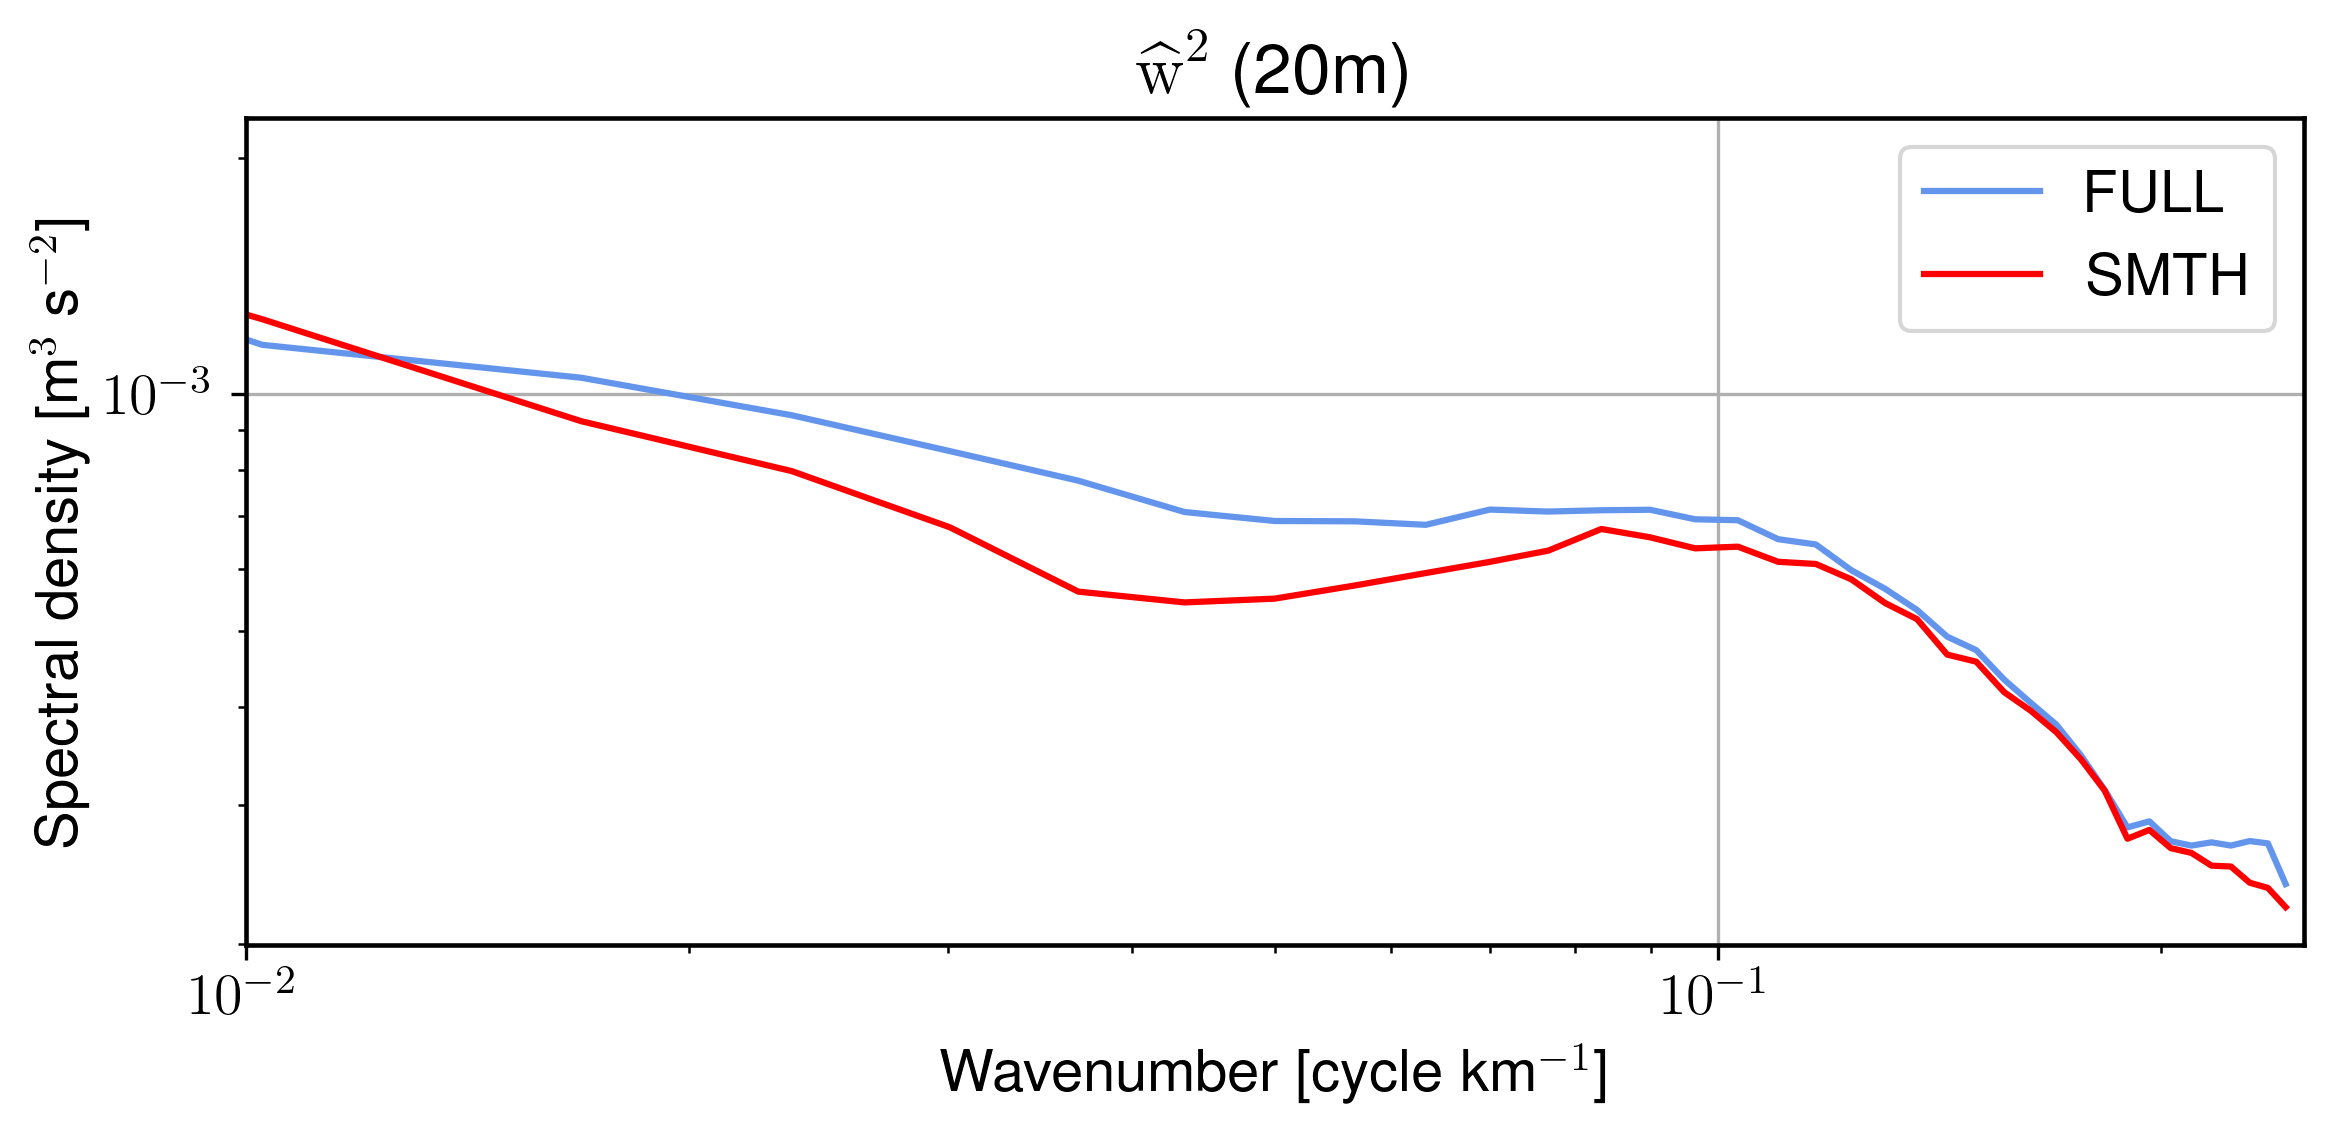

In [16]:
levw=1

plt.figure(figsize=(8,4),dpi=300)


plt.plot(w_full_spec['freq_r']/dxx*1e3,w_full_spec.isel(lev_W=levw).mean('time_counter')*dxx,label='FULL',color=color1)
plt.plot(w_smth_spec['freq_r']/dxx*1e3,w_smth_spec.isel(lev_W=levw).mean('time_counter')*dxx,label='SMTH',color=color2)

plt.legend()
plt.yscale('log')
plt.xscale('log')
plt.grid()
plt.xlabel(r'Wavenumber [cycle km$^{-1}$]')
plt.ylabel(r'Spectral density [m$^3$ s$^{-2}$]')
plt.title(r'$\widehat{\textrm{w}}^{2}$'+ ' ({0}m)'.format(np.round(Z.isel(lev_W=levw).mean().values).astype(int)))
# plt.title('Vertical velocity'+' ({0}m)'.format(np.round(Z.isel(lev_W=levw).mean().values).astype(int)))

plt.xlim(1e-2,1/4)
# plt.ylim(1e-1,1e3)
plt.tight_layout()

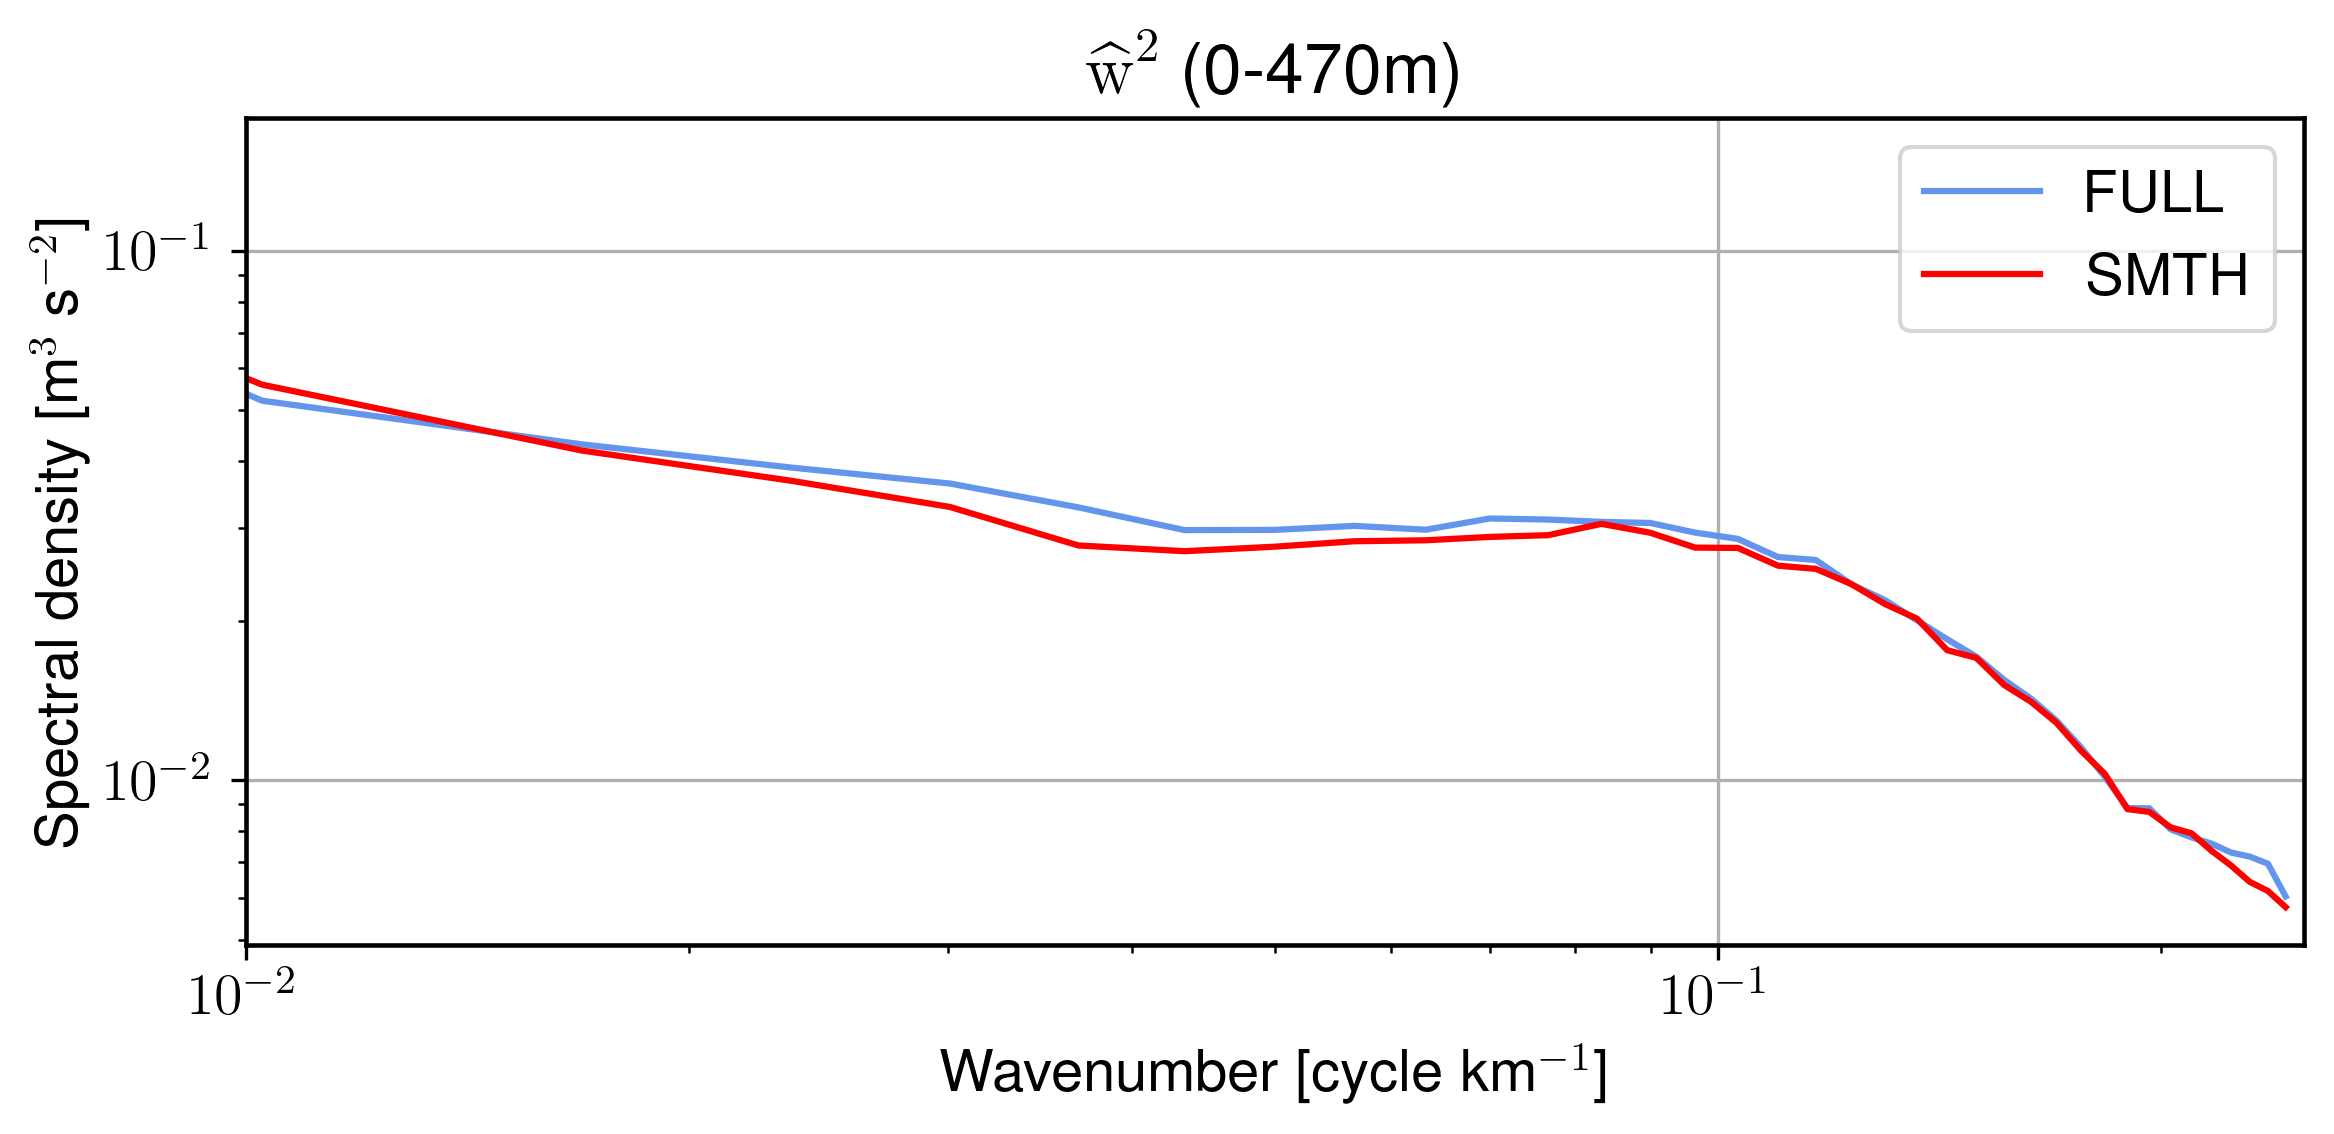

In [17]:
plt.figure(figsize=(8,4),dpi=300)

wmax=8
plt.plot(w_full_spec['freq_r']/dxx*1e3,w_full_spec.isel(lev_W=slice(0,wmax)).mean(['time_counter','lev_W'])*dxx,label='FULL',color=color1)
plt.plot(w_smth_spec['freq_r']/dxx*1e3,w_smth_spec.isel(lev_W=slice(0,wmax)).mean(['time_counter','lev_W'])*dxx,label='SMTH',color=color2)

plt.legend()
plt.yscale('log')
plt.xscale('log')
plt.grid()
plt.xlabel(r'Wavenumber [cycle km$^{-1}$]')
plt.ylabel(r'Spectral density [m$^3$ s$^{-2}$]')
plt.title(r'$\widehat{\textrm{w}}^{2}$'+ ' (0-{0}m)'.format(np.round(Z.isel(lev_W=wmax).max().values).astype(int)))
# plt.title('Vertical velocity'+' ({0}m)'.format(np.round(Z.isel(lev_W=levw).mean().values).astype(int)))

plt.xlim(1e-2,1/4)
# plt.ylim(1e-1,1e3)
plt.tight_layout()

## Variable spectrum

In [18]:
levm=0
# levw=0

'''Planetary boundary layer'''
# var_name='PBLH';var_str=[r'Spectral density [m$^3$]',
#                          r'$\widehat{\textrm{PBL}}^{2}$',1e3,2e7]

'''Cloud water mixing ratio'''
# var_name='QCLOUD';var_str=[r'Spectral density [kg$^{2}$ kg$^{-2}$ m]',
#                            r'$\widehat{w_{{cl}}}^{2}$ ' +' ({0}m)'.format(
#                                np.round(Z_m.isel(lev_W=levm).mean().values).astype(int)),1e-12,2e-7]

'''Water vapor mixing ratio'''
var_name='QVAPOR';var_str=[r'Spectral density [kg$^{2}$ kg$^{-2}$ m]',
                         r'$\widehat{{w_{{v}}}}^{2}$'+' ({0}m)'.format(
                               np.round(Z_m.isel(lev_W=levm).mean().values).astype(int)),1e-8,1e-4]

'''Precipitation'''
# var_name='RAIN';var_str=[r'Spectral density [mm$^2$ m]',
#                          r'$\widehat{\textrm{P}}^{2}$',1e3,2e7]

'''Perturbation dry air mass in column'''
# var_name='MU';var_str=[r'Spectral density [Pa$^2$ m]',
#                          r'$\widehat{{M_{\textrm{dry}}}}^{2}$',1e3,2e7]

'''Upward moisture flux'''
# var_name='QFX';var_str=[r'Spectral density [kg$^{2}$ m$^{-3}$ s$^{-2}$]',
#                          r'$\widehat{{Q_{w}}}^{2}$',1e-12,2e-6]

if 'lev_M' in varfw[var_name].dims:
    var_full=varfw[var_name].isel(x_grid_M=slice(0,xcoast),lev_M=levm)
    var_smth=vartw[var_name].isel(x_grid_M=slice(0,xcoast),lev_M=levm)
    
# elif 'lev_W' in varfw[var_name].dims:
#     var_full=varfw[var_name].isel(x_grid_M=slice(0,215),lev_W=levw)
#     var_smth=vartw[var_name].isel(x_grid_M=slice(0,215),lev_W=levw)
else:
    var_full=varfw[var_name].isel(x_grid_M=slice(0,xcoast))
    var_smth=vartw[var_name].isel(x_grid_M=slice(0,xcoast))

In [19]:
%%time
var_full_spec=xrft.isotropic_power_spectrum(var_full.drop(['nav_lat_grid_M', 'nav_lon_grid_M']),
                                          dim=['y_grid_M','x_grid_M'],scaling=sclstr,true_phase = phase_bol,
                                          truncate=truncate_bol, window=wdws,window_correction=wdw_cor)

var_smth_spec=xrft.isotropic_power_spectrum(var_smth.drop(['nav_lat_grid_M', 'nav_lon_grid_M']),
                                          dim=['y_grid_M','x_grid_M'],scaling=sclstr,true_phase = phase_bol,
                                          truncate=truncate_bol, window=wdws,window_correction=wdw_cor)

CPU times: user 2.32 s, sys: 6.32 s, total: 8.63 s
Wall time: 1min 40s


{'long_name': 'Water vapor mixing ratio', 'units': 'kg kg-1', 'online_operation': 'average', 'interval_operation': '12 s', 'interval_write': '1 d', 'cell_methods': 'time: mean (interval: 12 s)'}


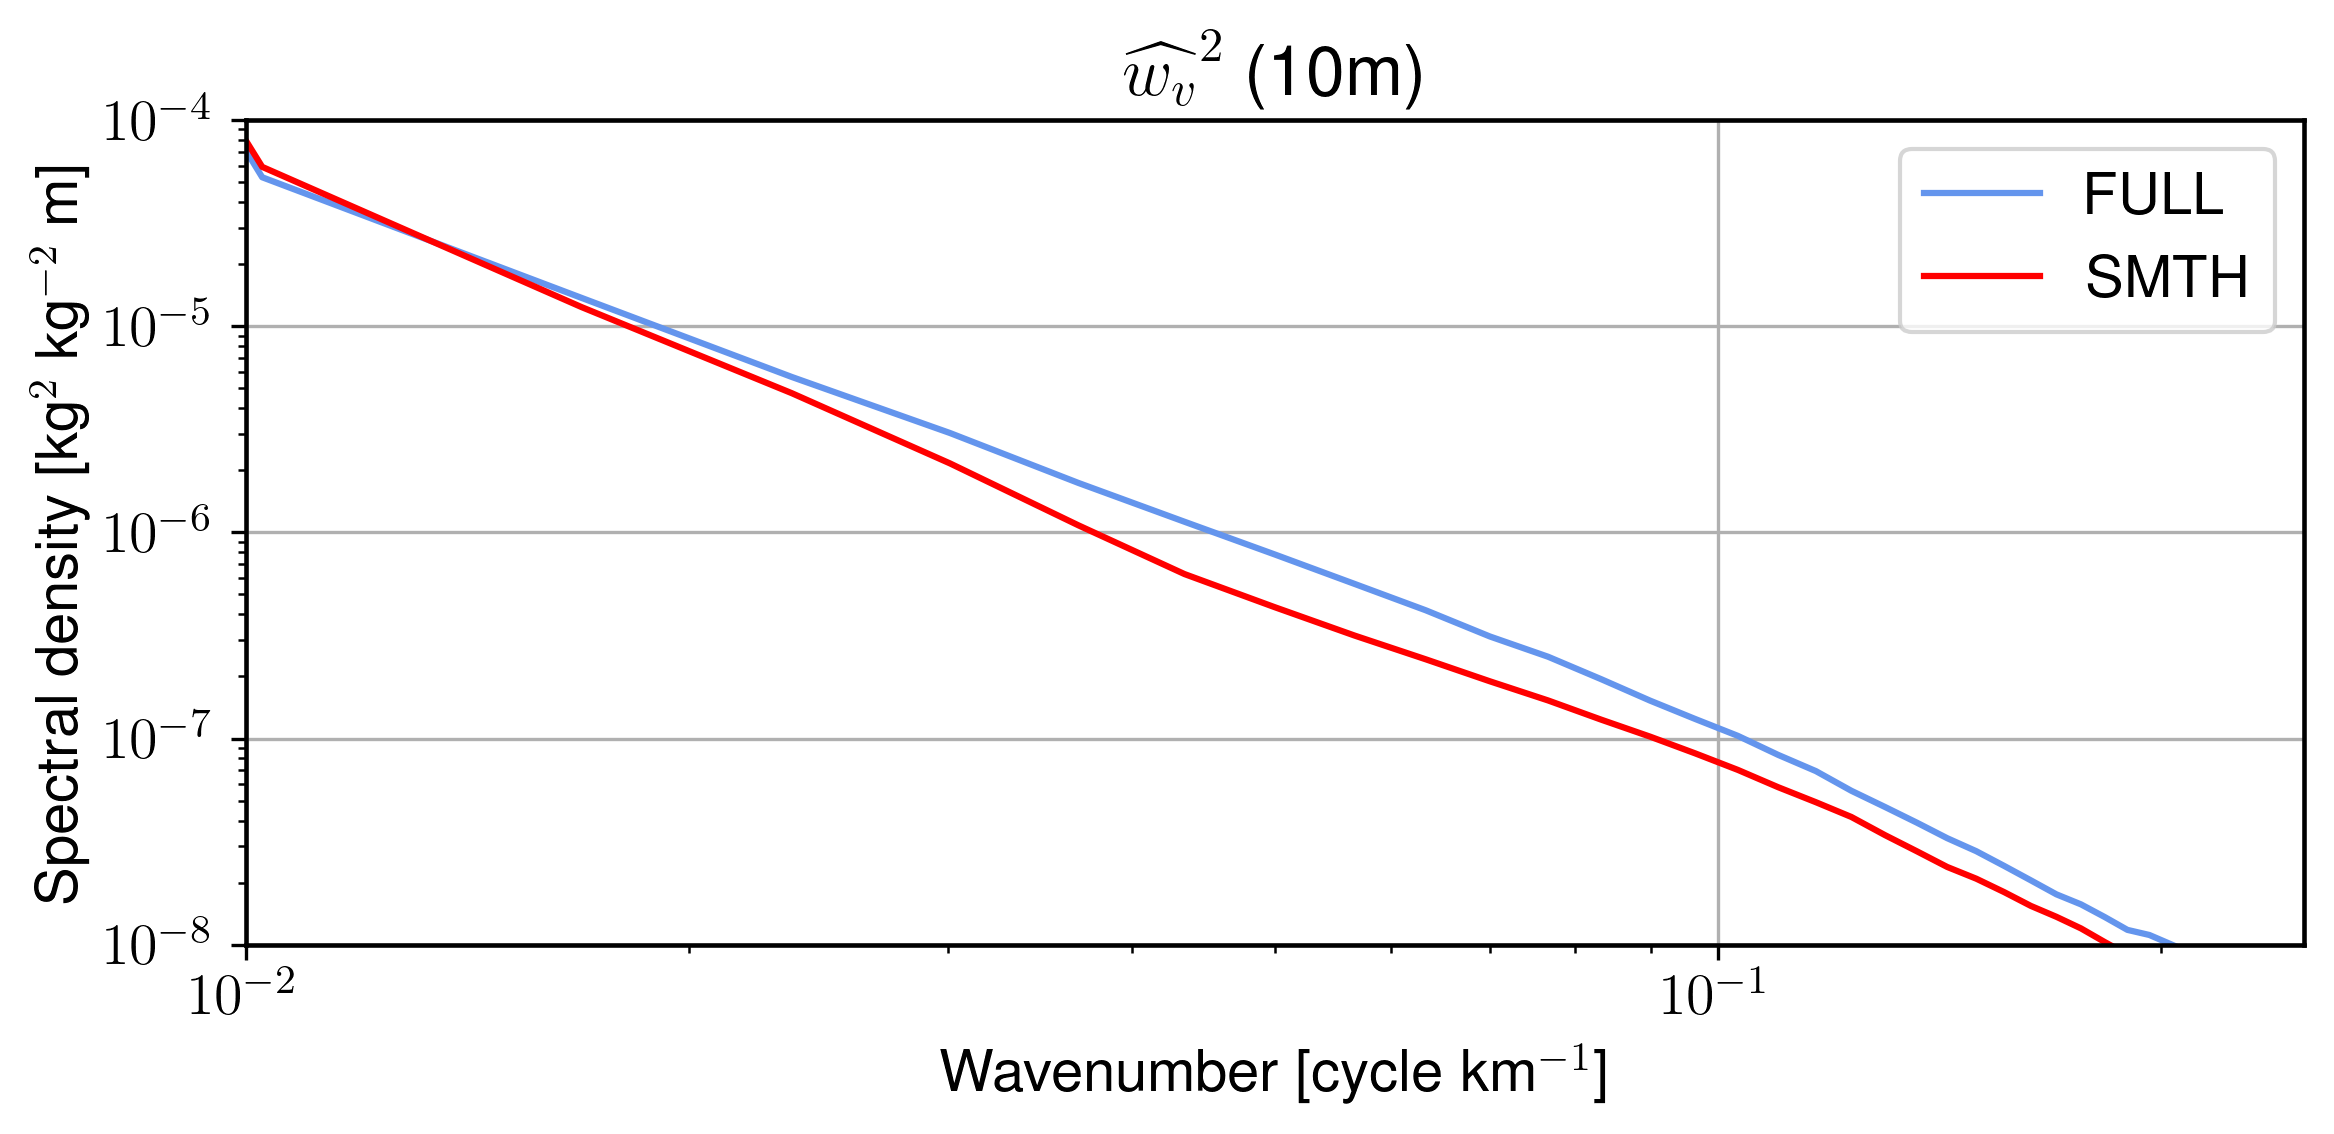

In [20]:
print(var_full.attrs)
plt.figure(figsize=(8,4),dpi=300)


plt.plot(var_full_spec['freq_r']/dxx*1e3,var_full_spec.mean('time_counter')*dxx,label='FULL',color=color1)
plt.plot(var_smth_spec['freq_r']/dxx*1e3,var_smth_spec.mean('time_counter')*dxx,label='SMTH',color=color2)

plt.legend()
plt.yscale('log')
plt.xscale('log')

plt.grid()
plt.xlabel(r'Wavenumber [cycle km$^{-1}$]')
plt.ylabel(var_str[0])
plt.title(var_str[1])

plt.xlim(1e-2,1/4)
plt.ylim(var_str[2],var_str[3])

plt.tight_layout()


## Variable Ogives

In [27]:
levm=0
levw=1

'''Planetary boundary layer'''
# var_name='PBLH';var_og=[r'[10 m$^2$]',
#                          r'$\widehat{\textrm{PBL}}^{2}$',-0.1,12,10]

'''Cloud water mixing ratio'''
# var_name='QCLOUD';var_og=[r'[10$^{-12}$ kg$^{2}$ kg$^{-2}$]',
#                            r'$\widehat{w_{{cl}}}^{2}$ ' +' ({0}m)'.format(
#                                np.round(Z_m.isel(lev_W=levm).mean().values).astype(int)),-0.1,2,1e-12]

'''Water vapor mixing ratio'''
# var_name='QVAPOR';var_og=[r'[10$^{-10}$ kg$^{2}$ kg$^{-2}$]',
#                          r'$\widehat{{w_{{v}}}}^{2}$'+' ({0}m)'.format(
#                                np.round(Z_m.isel(lev_W=levm).mean().values).astype(int)),-0.1,5,1e-10]

'''Precipitation'''
# var_name='RAIN';var_og=[r'[10$^{-9}$ mm$^2$]',
#                          r'$\widehat{\textrm{P}}^{2}$',-0.1,2.2,1e-9]

'''Perturbation dry air mass in column'''
# var_name='MU';var_og=[r'[10$^{-9}$ Pa$^2$]',
#                          r'$\widehat{{M_{\textrm{dry}}}}^{2}$',-0.1,3,1e-1]

'''Upward moisture flux'''
# var_name='QFX';var_og=[r'[10$^{-12}$ kg$^{2}$ m$^{-4}$ s$^{-2}$]',
#                          r'$\widehat{{Q_{w}}}^{2}$',0,2,1e-12]

"Vertical velocity"
var_name='W';var_og=[r'[10$^{-7}$ m$^{-2}$ s$^{-2}$]',
                         r'$\widehat{{{\mathrm{w}}}}^{2}$'+' ({0}m)'.format(
                               np.round(Z.isel(lev_W=levw).mean().values).astype(int)),0,2,1e-7]

if 'lev_M' in varfw[var_name].dims:
    var_full=varfw[var_name].isel(x_grid_M=slice(0,xcoast),lev_M=levm)
    var_smth=vartw[var_name].isel(x_grid_M=slice(0,xcoast),lev_M=levm)
    
elif 'lev_W' in varfw[var_name].dims:
    var_full=varfw[var_name].isel(x_grid_M=slice(0,xcoast),lev_W=levw)
    var_smth=vartw[var_name].isel(x_grid_M=slice(0,xcoast),lev_W=levw)
else:
    var_full=varfw[var_name].isel(x_grid_M=slice(0,xcoast))
    var_smth=vartw[var_name].isel(x_grid_M=slice(0,xcoast))

In [28]:
%%time
var_full_spec=xrft.isotropic_power_spectrum(var_full.drop(['nav_lat_grid_M', 'nav_lon_grid_M']),
                                          dim=['y_grid_M','x_grid_M'],scaling=sclstr,true_phase = phase_bol,
                                          truncate=truncate_bol, window=wdws,window_correction=wdw_cor)

var_smth_spec=xrft.isotropic_power_spectrum(var_smth.drop(['nav_lat_grid_M', 'nav_lon_grid_M']),
                                          dim=['y_grid_M','x_grid_M'],scaling=sclstr,true_phase = phase_bol,
                                          truncate=truncate_bol, window=wdws,window_correction=wdw_cor)

CPU times: user 2.33 s, sys: 2.36 s, total: 4.69 s
Wall time: 2.47 s


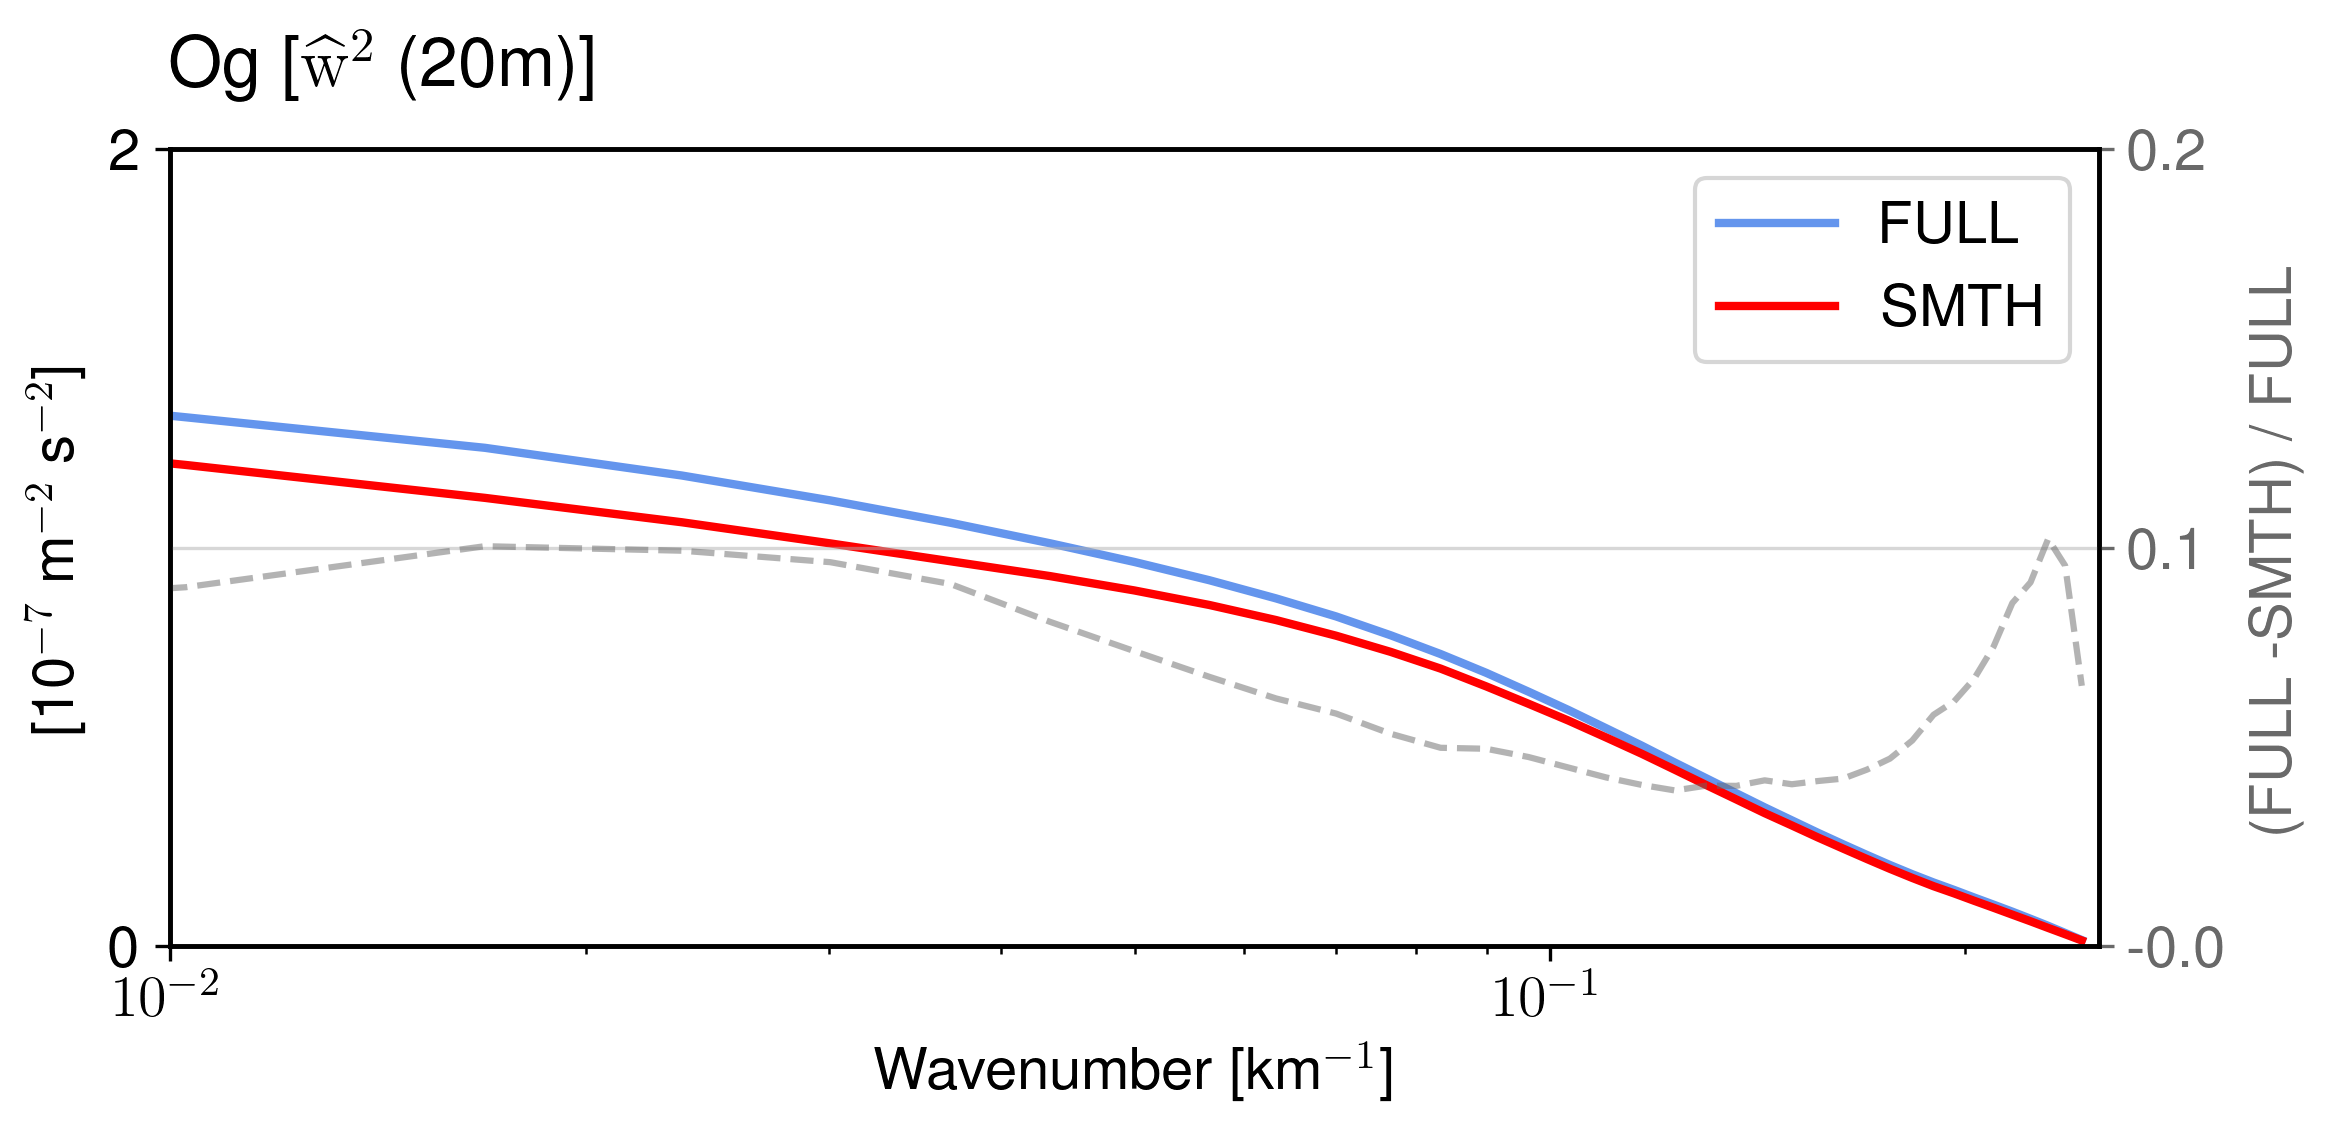

In [29]:
KAf=ogive(np.diff(var_full_spec['freq_r']/dxx).mean(),(var_full_spec.mean('time_counter')*dxx)) #in metersss
KAt=ogive(np.diff(var_smth_spec['freq_r']/dxx).mean(),(var_smth_spec.mean('time_counter')*dxx)) #in metersss
Kxa=var_full_spec['freq_r']/dxx*1e3 #in Kilometers

Kff=var_og[4]

plt.figure(figsize=(8,4),dpi=300)
ax1=plt.subplot(1,1,1)          
ax1.plot(Kxa,KAf/Kff,label='FULL',linewidth=2,color=color1)
ax1.plot(Kxa,KAt/Kff,label='SMTH',linewidth=2,color=color2)
ax1.set_xscale('log')
# ax1.set_yscale('log')

ax1.set_title(r'Og [{0}]'.format(var_og[1]),fontweight='bold',loc='left',pad=15)


ax1.set_xlabel(r'Wavenumber  [km$^{-1}$]',fontweight='bold')
ax1.set_ylabel('{0}'.format(var_og[0]),fontweight='bold',labelpad=5)

ax1.set_xlim(1e-2,1/4)
# ax1.set_ylim(-0.1,125)

ax1.set_yticks(np.arange(0,125,2))
ax1.set_yticklabels(np.arange(0,125,2).astype(str))

ax1.set_ylim(var_og[2],var_og[3])


ax1.legend()

ax12=ax1.twinx()
Og_Ratio=((KAf-KAt)/(KAf))
ax12.plot((Kxa),Og_Ratio,alpha=0.5,linestyle='dashed',color='dimgray')

# ax12.set_ylabel(r'($\frac{\mathrm{FULL} - \mathrm{SMTH}}{\mathrm{FULL}}$)',fontsize=18,color='dimgray')
ax12.set_ylabel(r'(FULL -SMTH) / FULL',color='dimgray',labelpad=5)

ax12.set_xscale('log')
ax12.set_yticks(np.arange(-0.8,0.9,0.1),labels=np.round(np.arange(-0.8,0.9,0.1),1).astype(str))
# ax12.set_ylim(Og_Ratio.mean()-4*Og_Ratio.std(),Og_Ratio.mean()+4*Og_Ratio.std())
ax12.set_ylim(-0,0.2)


# ax12.set_yticklabels(['-0.2','-0.1'])

ax12.grid(alpha=0.5)
ax12.tick_params(axis='y', colors='dimgray')
plt.tight_layout()

### Averages

In [24]:
maxlevm=9
maxlevw=9

'''Cloud water mixing ratio'''
# var_name='QCLOUD';var_og=[r'[10$^{-12}$ kg$^{2}$ kg$^{-2}$]',
#                            r'$\widehat{w_{{cl}}}^{2}$ ' +' (0-{0}m)'.format(
#                                np.round(Z_m.isel(lev_W=slice(0,maxlv)).max().values).astype(int)),-0.1,3,1e-12]

'''Water vapor mixing ratio'''
var_name='QVAPOR';var_og=[r'[10$^{-10}$ kg$^{2}$ kg$^{-2}$]',
                         r'$\widehat{{w_{{v}}}}^{2}$'+' (0-{0}m)'.format(
                               np.round(Z_m.isel(lev_W=slice(0,maxlevm)).max().values).astype(int)),-0.1,5,1e-10]

"Vertical velocity"
var_name='W';var_og=[r'[10$^{-6}$ m$^{-2}$ s$^{-2}$]',
                         r'$\widehat{{{\mathrm{w}}}}^{2}$'+' (0-{0}m)'.format(
                               np.round(Z.isel(lev_W=slice(0,maxlevw)).max().values).astype(int)),0,7,1e-6]


if 'lev_M' in varfw[var_name].dims:
    var_full=varfw[var_name].isel(x_grid_M=slice(0,xcoast),lev_M=slice(0,maxlevm))
    var_smth=vartw[var_name].isel(x_grid_M=slice(0,xcoast),lev_M=slice(0,maxlevm))
    
elif 'lev_W' in varfw[var_name].dims:
    var_full=varfw[var_name].isel(x_grid_M=slice(0,xcoast),lev_W=slice(0,maxlevw))
    var_smth=vartw[var_name].isel(x_grid_M=slice(0,xcoast),lev_W=slice(0,maxlevw))
else:
    var_full=varfw[var_name].isel(x_grid_M=slice(0,xcoast))
    var_smth=vartw[var_name].isel(x_grid_M=slice(0,xcoast))

In [25]:
%%time
var_full_spec=xrft.isotropic_power_spectrum(var_full.drop(['nav_lat_grid_M', 'nav_lon_grid_M']),
                                          dim=['y_grid_M','x_grid_M'],scaling=sclstr,true_phase = phase_bol,
                                          truncate=truncate_bol, window=wdws,window_correction=wdw_cor)

var_smth_spec=xrft.isotropic_power_spectrum(var_smth.drop(['nav_lat_grid_M', 'nav_lon_grid_M']),
                                          dim=['y_grid_M','x_grid_M'],scaling=sclstr,true_phase = phase_bol,
                                          truncate=truncate_bol, window=wdws,window_correction=wdw_cor)

CPU times: user 19 s, sys: 6.7 s, total: 25.7 s
Wall time: 5.46 s


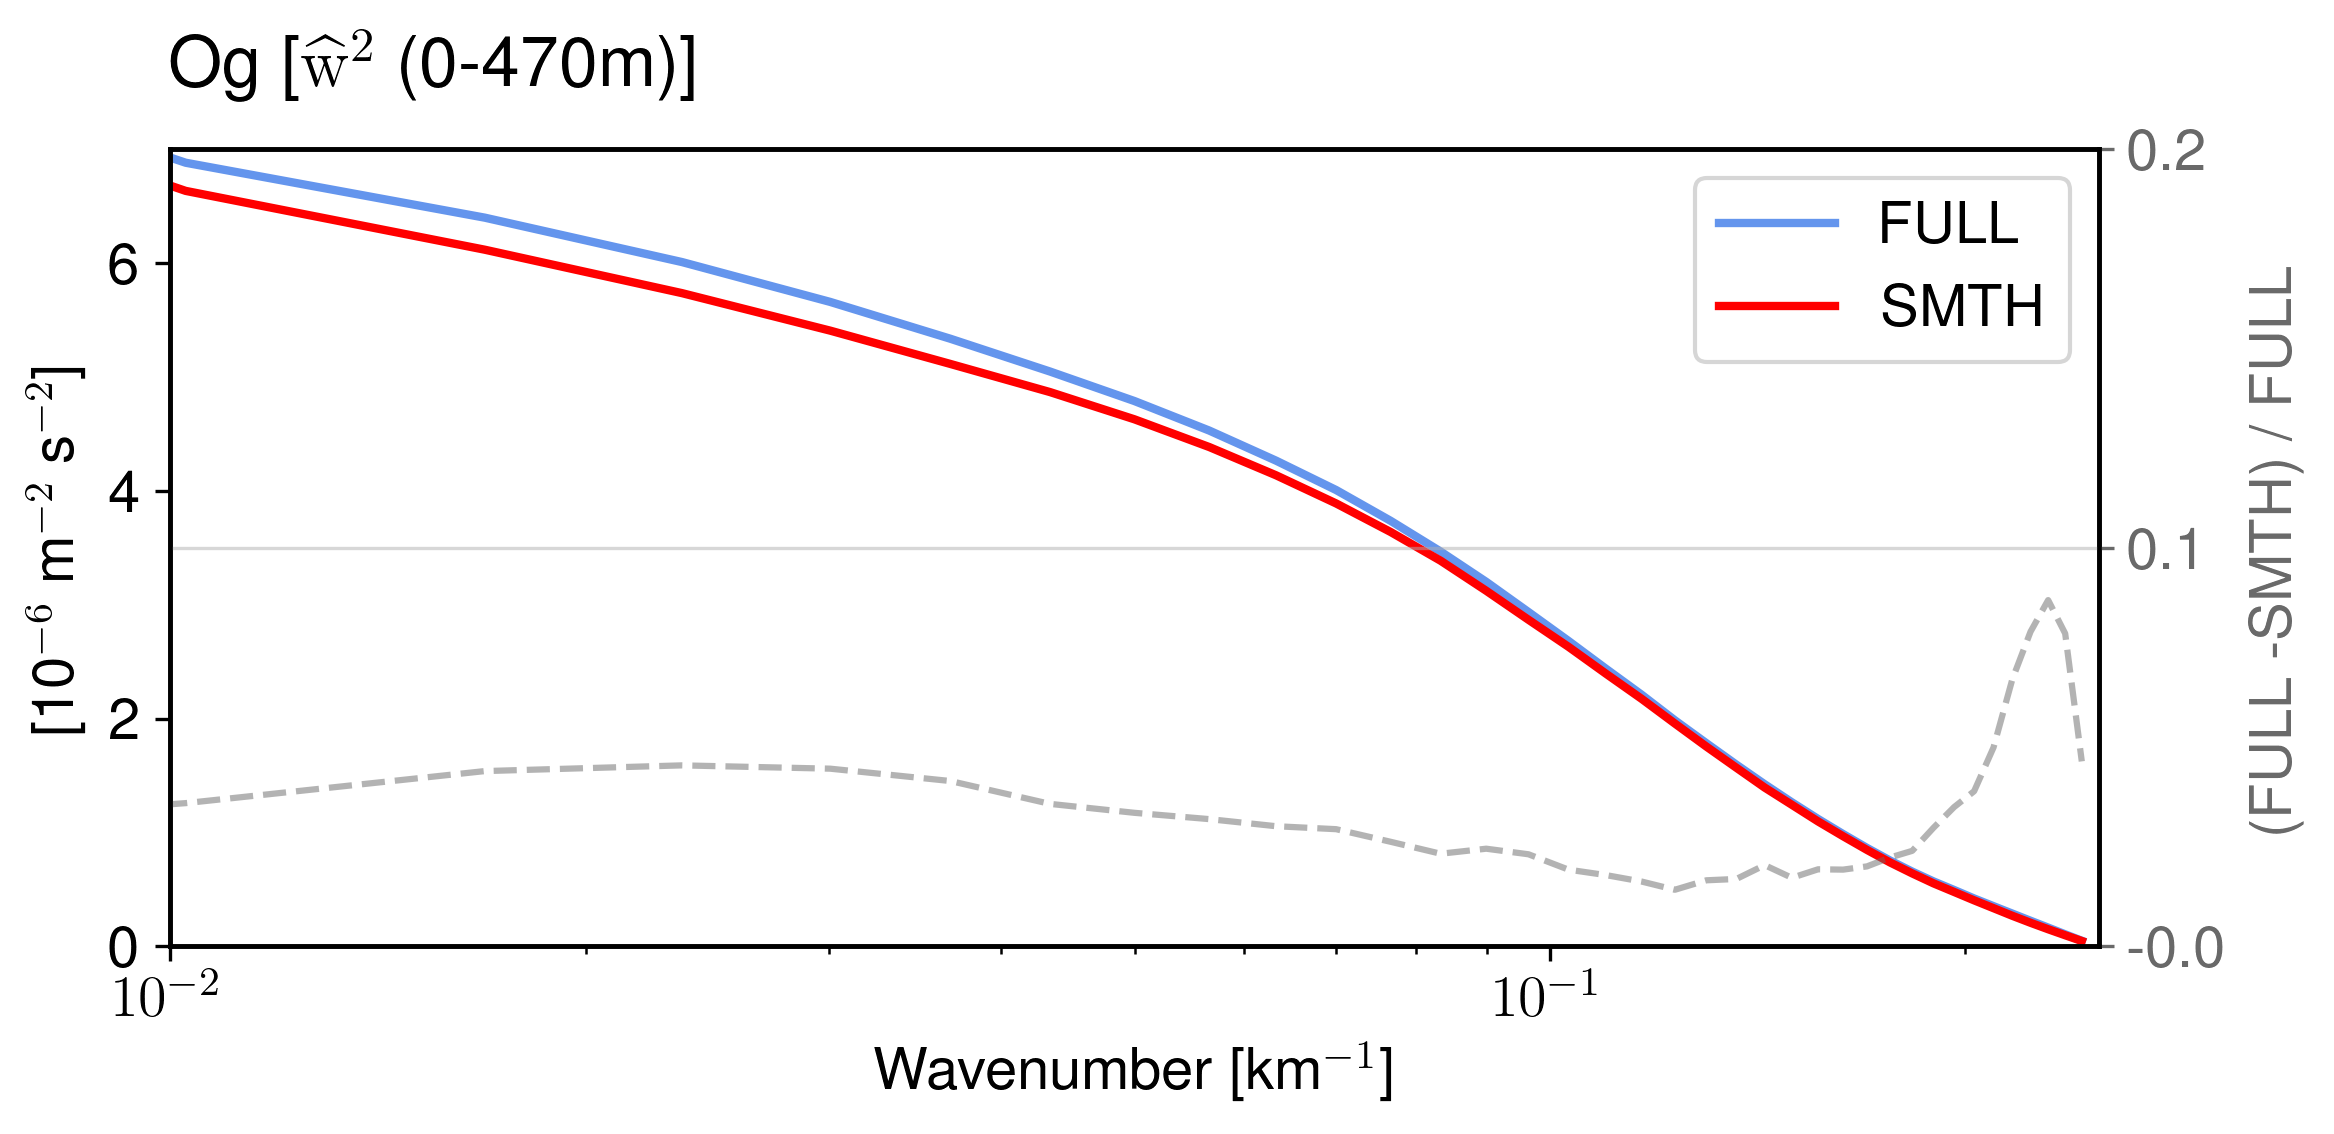

In [26]:
KAf=ogive(np.diff(var_full_spec['freq_r']/dxx).mean(),(var_full_spec.mean(axis=[0,1])*dxx)) #in metersss
KAt=ogive(np.diff(var_smth_spec['freq_r']/dxx).mean(),(var_smth_spec.mean(axis=[0,1])*dxx)) #in metersss
Kxa=var_full_spec['freq_r']/dxx*1e3 #in Kilometers

Kff=var_og[4]

plt.figure(figsize=(8,4),dpi=300)
ax1=plt.subplot(1,1,1)          
ax1.plot(Kxa,KAf/Kff,label='FULL',linewidth=2,color=color1)
ax1.plot(Kxa,KAt/Kff,label='SMTH',linewidth=2,color=color2)
ax1.set_xscale('log')
# ax1.set_yscale('log')

ax1.set_title(r'Og [{0}]'.format(var_og[1]),fontweight='bold',loc='left',pad=15)


ax1.set_xlabel(r'Wavenumber  [km$^{-1}$]',fontweight='bold')
ax1.set_ylabel('{0}'.format(var_og[0]),fontweight='bold',labelpad=5)

ax1.set_xlim(1e-2,1/4)
# ax1.set_ylim(-0.1,125)

ax1.set_yticks(np.arange(0,125,2))
ax1.set_yticklabels(np.arange(0,125,2).astype(str))

ax1.set_ylim(var_og[2],var_og[3])


ax1.legend()

ax12=ax1.twinx()
Og_Ratio=((KAf-KAt)/(KAf))
ax12.plot((Kxa),Og_Ratio,alpha=0.5,linestyle='dashed',color='dimgray')

# ax12.set_ylabel(r'($\frac{\mathrm{FULL} - \mathrm{SMTH}}{\mathrm{FULL}}$)',fontsize=18,color='dimgray')
ax12.set_ylabel(r'(FULL -SMTH) / FULL',color='dimgray',labelpad=5)

ax12.set_xscale('log')
ax12.set_yticks(np.arange(-0.8,0.9,0.1),labels=np.round(np.arange(-0.8,0.9,0.1),1).astype(str))
# ax12.set_ylim(Og_Ratio.mean()-4*Og_Ratio.std(),Og_Ratio.mean()+2*Og_Ratio.std())
ax12.set_ylim(0,0.2)

# ax12.set_yticklabels(['-0.2','-0.1'])

ax12.grid(alpha=0.5)
ax12.tick_params(axis='y', colors='dimgray')
plt.tight_layout()

## w x SST co-spectrum (NEED TO REGRID SST)

In [ ]:
%%time
levw=2
w_sst_full_cospec=xrft.isotropic_cross_spectrum(sst_full.drop(['nav_lat_grid_M', 'nav_lon_grid_M']),
                                                w_full.isel(lev_W=levw).drop(['nav_lat_grid_M', 'nav_lon_grid_M']),
                                          dim=['y_grid_M','x_grid_M'],scaling=sclstr,true_phase = phase_bol,
                                          truncate=truncate_bol, window=wdws,window_correction=wdw_cor).real


w_sst_smth_cospec=xrft.isotropic_cross_spectrum(sst_smth.drop(['nav_lat_grid_M', 'nav_lon_grid_M']),
                                                w_smth.isel(lev_W=levw).drop(['nav_lat_grid_M', 'nav_lon_grid_M']),
                                          dim=['y_grid_M','x_grid_M'],scaling=sclstr,true_phase = phase_bol,
                                          truncate=truncate_bol, window=wdws,window_correction=wdw_cor).real

In [ ]:

plt.figure(figsize=(8,4),dpi=300)


plt.plot(w_sst_full_cospec['freq_r']/dxx*1e3,w_sst_full_cospec.mean('time_counter')*dxx,label='FULL',color=color1)
plt.plot(w_sst_smth_cospec['freq_r']/dxx*1e3,w_sst_smth_cospec.mean('time_counter')*dxx,label='SMTH',color=color2)

plt.legend()
plt.yscale('symlog', linthresh=1e-2)
plt.xscale('log')
plt.grid()
plt.xlabel(r'Wavenumber [cycle km$^{-1}$]')
plt.ylabel(r'Spectral density [m$^2$ $^{\circ}$C s$^{-1}$]')
plt.title(r'$Re$ $[\widehat{\textrm{SST}}$ $\widehat{\textrm{w}}]$'+' ({0}m)'.format(np.round(Z.isel(lev_W=levw).mean().values).astype(int)))
plt.xlim(1e-2,1/4)
plt.ylim(-2e-1,1e-1)
plt.tight_layout()

## PBL x SST co-spectrum (NEED TO REGRID SST)

In [107]:
%%time
pbl_sst_full_cospec=xrft.isotropic_cross_spectrum(sst_full.drop(['nav_lat_grid_M', 'nav_lon_grid_M']),
                                                  pbl_full.drop(['nav_lat_grid_M', 'nav_lon_grid_M']),
                                          dim=['y_grid_M','x_grid_M'],scaling=sclstr,true_phase = phase_bol,
                                          truncate=truncate_bol, window=wdws,window_correction=wdw_cor).real


pbl_sst_smth_cospec=xrft.isotropic_cross_spectrum(sst_smth.drop(['nav_lat_grid_M', 'nav_lon_grid_M']),
                                                  pbl_smth.drop(['nav_lat_grid_M', 'nav_lon_grid_M']),
                                          dim=['y_grid_M','x_grid_M'],scaling=sclstr,true_phase = phase_bol,
                                          truncate=truncate_bol, window=wdws,window_correction=wdw_cor).real

CPU times: user 2.9 s, sys: 892 ms, total: 3.79 s
Wall time: 3.8 s


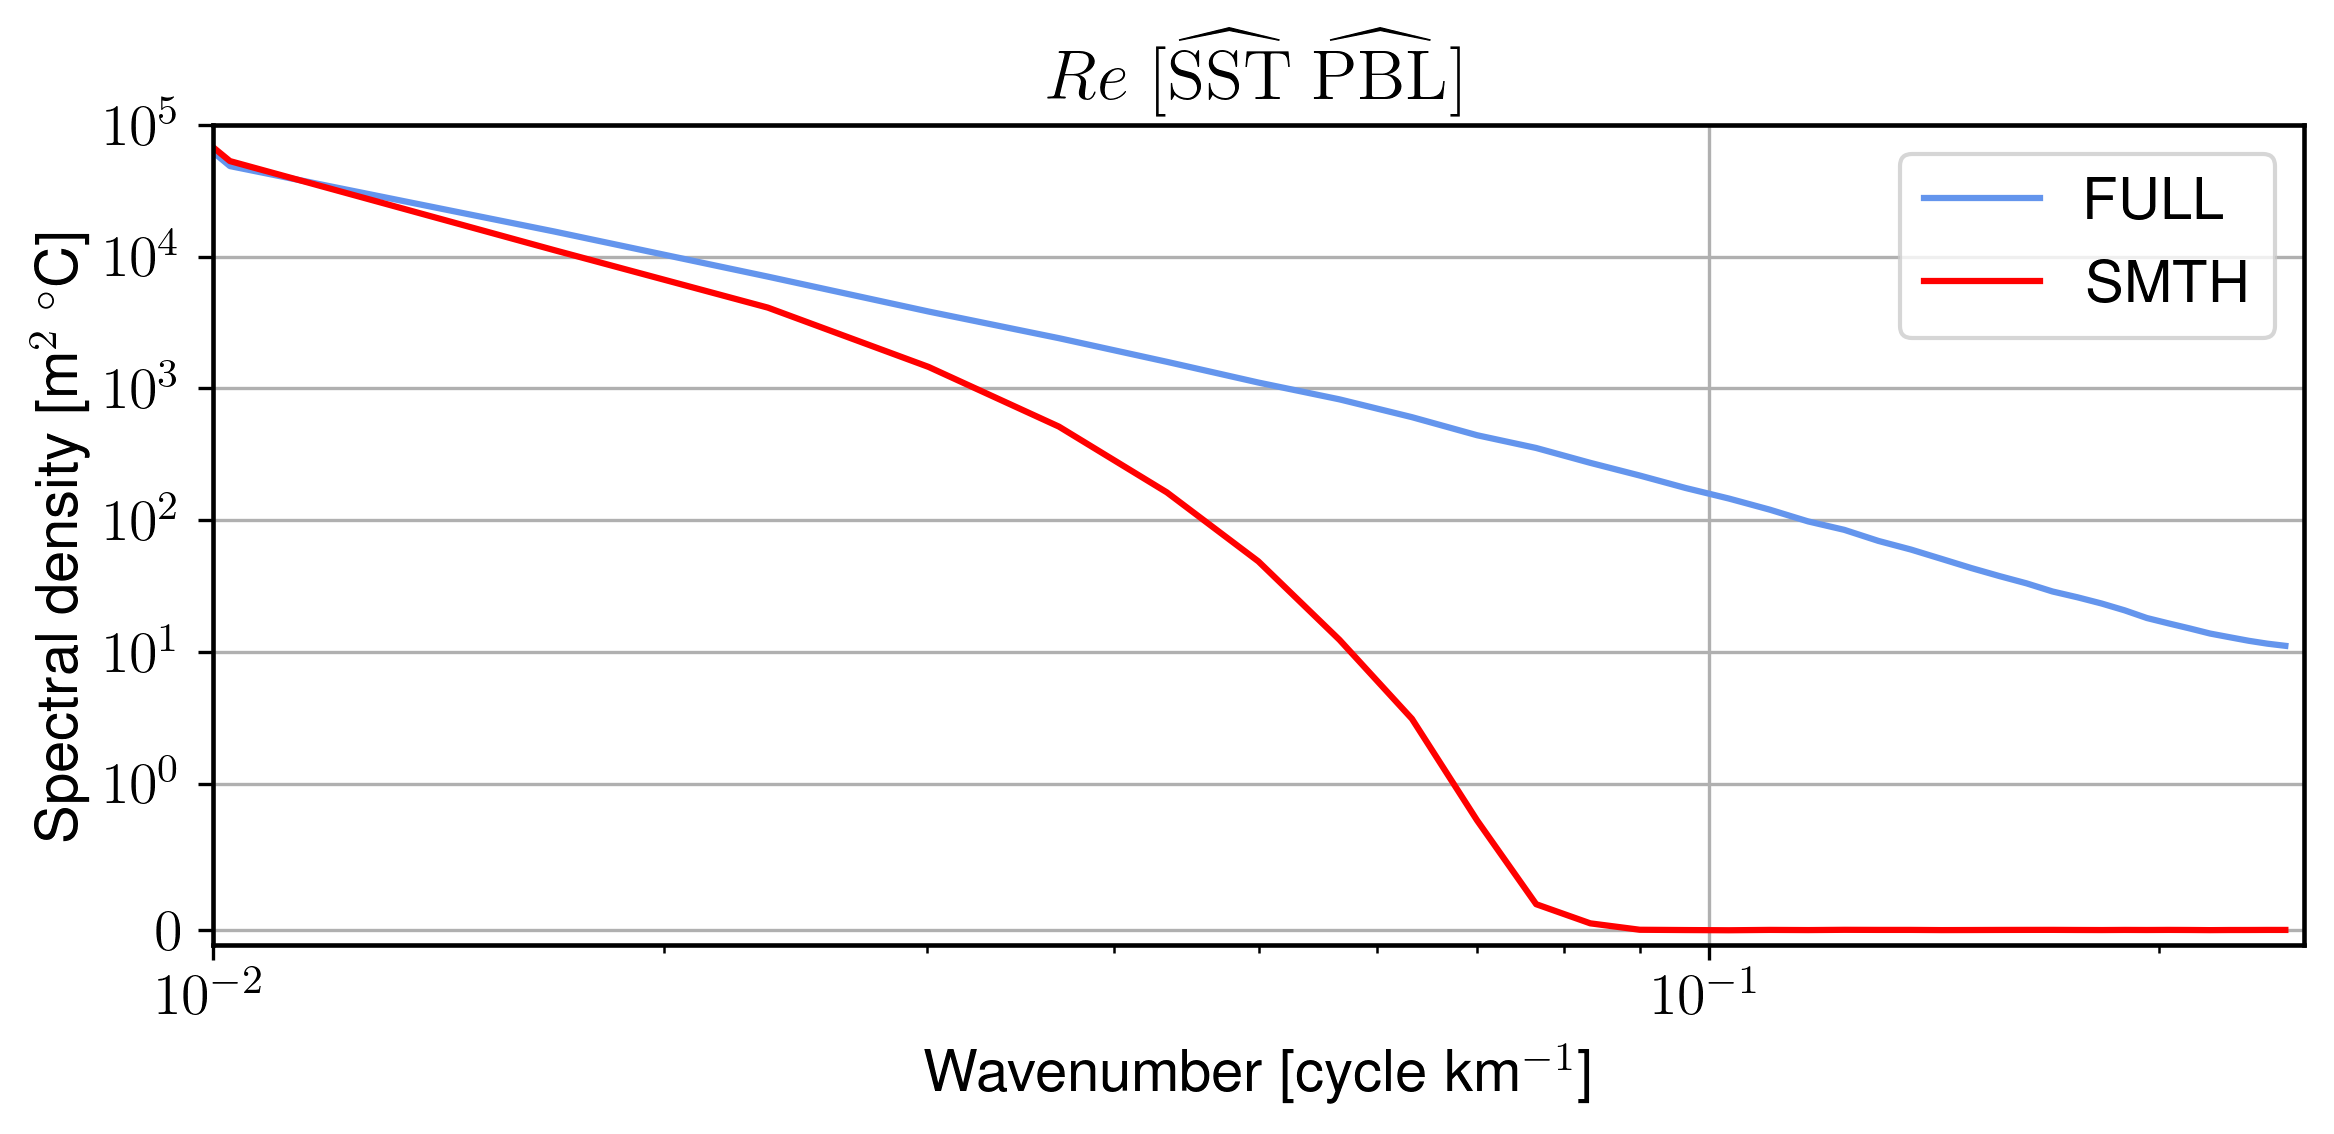

In [108]:

plt.figure(figsize=(8,4),dpi=300)


plt.plot(pbl_sst_full_cospec['freq_r']/dxx*1e3,pbl_sst_full_cospec.mean('time_counter')*dxx,label='FULL',color=color1)
plt.plot(pbl_sst_smth_cospec['freq_r']/dxx*1e3,pbl_sst_smth_cospec.mean('time_counter')*dxx,label='SMTH',color=color2)

plt.legend()
plt.yscale('symlog', linthresh=1)
plt.xscale('log')
plt.grid()
plt.xlabel(r'Wavenumber [cycle km$^{-1}$]')
plt.ylabel(r'Spectral density [m$^2$ $^{\circ}$C]')

plt.title(r'$Re$ $[\widehat{\textrm{SST}}$ $\widehat{\textrm{PBL}}]$')
plt.xlim(1e-2,1/4)
plt.ylim(-1e-1,1e5)
plt.tight_layout()